# Random Forest

#### Imports

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd

from src.rf_experiment import RandomForestExperiment
from src.utils import evaluate_model, save_results

c:\Users\renan\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Experimento 1: Conjunto com todas as Features

In [2]:
import pandas as pd
caminho = '../'

X_test_exp1 = pd.read_csv(caminho + 'database/processed/splitted/X_test.csv')
X_train_exp1 = pd.read_csv(caminho + 'database/processed/splitted/X_train.csv')
y_test_exp1 = pd.read_csv(caminho + 'database/processed/splitted/y_test.csv').squeeze()
y_train_exp1 = pd.read_csv(caminho + 'database/processed/splitted/y_train.csv').squeeze()

### RF - Default

In [3]:
from sklearn.ensemble import RandomForestClassifier

rf_exp1 = RandomForestClassifier(n_estimators=100, random_state=14)
rf_exp1.fit(X_train_exp1, y_train_exp1)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


=== Métricas rf_def_exp1  ===
    Acurácia: 0.7928
    Precisão: 0.7751
    Recall:   0.7311
    F1-Score: 0.7451
    MCC:      0.5043
    AUC:      0.8469


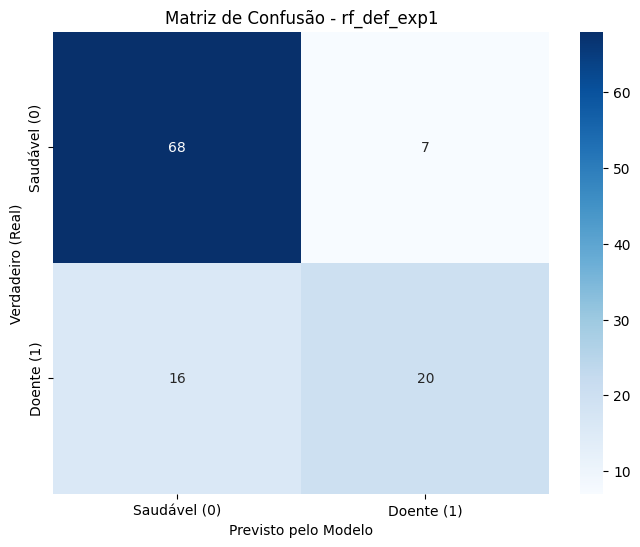

In [4]:
# Avaliar modelo
y_pred_def_exp1 = rf_exp1.predict(X_test_exp1)
y_prob_def_exp1 = rf_exp1.predict_proba(X_test_exp1)[:, 1]

evaluate_model(y_test_exp1, y_pred_def_exp1, y_prob_def_exp1, 'rf_def_exp1')
save_results(y_pred_def_exp1, y_prob_def_exp1, 'rf_def_exp1', caminho)

### RF - Melhorado

In [5]:
# Criar o experimento
experimento_1 = RandomForestExperiment(X_train_exp1, y_train_exp1, 'rf_otz_exp1', caminho)
experimento_1.tune_and_fit(n_trials=50)
best_rf = experimento_1.best_model

[I 2026-08-18 19:04:33,249] A new study created in memory with name: no-name-9ca633ce-6d43-4e93-9230-c7194050cac6


Iniciando otimização do cenário rf_otz_exp1.


Best trial: 0. Best value: 0.775194:   2%|▏         | 1/50 [00:06<05:12,  6.37s/it]

[I 2026-08-18 19:04:39,610] Trial 0 finished with value: 0.7751937984496124 and parameters: {'n_estimators': 196, 'max_depth': 3, 'min_samples_split': 5, 'min_samples_leaf': 9, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 0 with value: 0.7751937984496124.


Best trial: 1. Best value: 0.794574:   4%|▍         | 2/50 [00:12<05:00,  6.25s/it]

[I 2026-08-18 19:04:45,780] Trial 1 finished with value: 0.7945736434108528 and parameters: {'n_estimators': 91, 'max_depth': 18, 'min_samples_split': 2, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 1 with value: 0.7945736434108528.


Best trial: 2. Best value: 0.810078:   6%|▌         | 3/50 [00:19<05:06,  6.52s/it]

[I 2026-08-18 19:04:52,621] Trial 2 finished with value: 0.810077519379845 and parameters: {'n_estimators': 238, 'max_depth': 11, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 2 with value: 0.810077519379845.


Best trial: 2. Best value: 0.810078:   8%|▊         | 4/50 [00:25<04:45,  6.20s/it]

[I 2026-08-18 19:04:58,331] Trial 3 finished with value: 0.8062015503875969 and parameters: {'n_estimators': 163, 'max_depth': 18, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 2 with value: 0.810077519379845.


Best trial: 4. Best value: 0.813953:  10%|█         | 5/50 [00:25<03:10,  4.24s/it]

[I 2026-08-18 19:04:59,093] Trial 4 finished with value: 0.813953488372093 and parameters: {'n_estimators': 276, 'max_depth': 9, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 4 with value: 0.813953488372093.


Best trial: 4. Best value: 0.813953:  12%|█▏        | 6/50 [00:26<02:08,  2.91s/it]

[I 2026-08-18 19:04:59,432] Trial 5 finished with value: 0.8062015503875969 and parameters: {'n_estimators': 126, 'max_depth': 10, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'gini'}. Best is trial 4 with value: 0.813953488372093.


Best trial: 4. Best value: 0.813953:  14%|█▍        | 7/50 [00:26<01:32,  2.16s/it]

[I 2026-08-18 19:05:00,035] Trial 6 finished with value: 0.7984496124031009 and parameters: {'n_estimators': 243, 'max_depth': 16, 'min_samples_split': 5, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 4 with value: 0.813953488372093.


Best trial: 4. Best value: 0.813953:  16%|█▌        | 8/50 [00:27<01:07,  1.61s/it]

[I 2026-08-18 19:05:00,478] Trial 7 finished with value: 0.810077519379845 and parameters: {'n_estimators': 161, 'max_depth': 14, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 4 with value: 0.813953488372093.


Best trial: 4. Best value: 0.813953:  18%|█▊        | 9/50 [00:28<00:55,  1.35s/it]

[I 2026-08-18 19:05:01,248] Trial 8 finished with value: 0.7984496124031008 and parameters: {'n_estimators': 267, 'max_depth': 5, 'min_samples_split': 3, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 4 with value: 0.813953488372093.


Best trial: 9. Best value: 0.821705:  20%|██        | 10/50 [00:28<00:45,  1.15s/it]

[I 2026-08-18 19:05:01,952] Trial 9 finished with value: 0.8217054263565892 and parameters: {'n_estimators': 273, 'max_depth': 16, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'gini'}. Best is trial 9 with value: 0.8217054263565892.


Best trial: 9. Best value: 0.821705:  22%|██▏       | 11/50 [00:29<00:40,  1.04s/it]

[I 2026-08-18 19:05:02,740] Trial 10 finished with value: 0.8217054263565892 and parameters: {'n_estimators': 300, 'max_depth': 20, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 9 with value: 0.8217054263565892.


Best trial: 11. Best value: 0.825581:  24%|██▍       | 12/50 [00:30<00:36,  1.04it/s]

[I 2026-08-18 19:05:03,521] Trial 11 finished with value: 0.8255813953488372 and parameters: {'n_estimators': 296, 'max_depth': 19, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 11 with value: 0.8255813953488372.


Best trial: 11. Best value: 0.825581:  26%|██▌       | 13/50 [00:30<00:31,  1.19it/s]

[I 2026-08-18 19:05:04,089] Trial 12 finished with value: 0.8178294573643411 and parameters: {'n_estimators': 210, 'max_depth': 14, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 11 with value: 0.8255813953488372.


Best trial: 11. Best value: 0.825581:  28%|██▊       | 14/50 [00:31<00:29,  1.21it/s]

[I 2026-08-18 19:05:04,887] Trial 13 finished with value: 0.813953488372093 and parameters: {'n_estimators': 299, 'max_depth': 20, 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 11 with value: 0.8255813953488372.


Best trial: 11. Best value: 0.825581:  30%|███       | 15/50 [00:31<00:22,  1.57it/s]

[I 2026-08-18 19:05:05,080] Trial 14 finished with value: 0.810077519379845 and parameters: {'n_estimators': 57, 'max_depth': 15, 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 'log2', 'criterion': 'gini'}. Best is trial 11 with value: 0.8255813953488372.


Best trial: 11. Best value: 0.825581:  32%|███▏      | 16/50 [00:32<00:21,  1.56it/s]

[I 2026-08-18 19:05:05,741] Trial 15 finished with value: 0.8217054263565892 and parameters: {'n_estimators': 235, 'max_depth': 18, 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 11 with value: 0.8255813953488372.


Best trial: 11. Best value: 0.825581:  34%|███▍      | 17/50 [00:33<00:21,  1.53it/s]

[I 2026-08-18 19:05:06,416] Trial 16 finished with value: 0.8062015503875969 and parameters: {'n_estimators': 267, 'max_depth': 13, 'min_samples_split': 7, 'min_samples_leaf': 5, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 11 with value: 0.8255813953488372.


Best trial: 11. Best value: 0.825581:  36%|███▌      | 18/50 [00:33<00:19,  1.61it/s]

[I 2026-08-18 19:05:06,963] Trial 17 finished with value: 0.7790697674418605 and parameters: {'n_estimators': 217, 'max_depth': 17, 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_features': 'log2', 'criterion': 'gini'}. Best is trial 11 with value: 0.8255813953488372.


Best trial: 11. Best value: 0.825581:  38%|███▊      | 19/50 [00:34<00:20,  1.53it/s]

[I 2026-08-18 19:05:07,695] Trial 18 finished with value: 0.813953488372093 and parameters: {'n_estimators': 267, 'max_depth': 20, 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'log2', 'criterion': 'gini'}. Best is trial 11 with value: 0.8255813953488372.


Best trial: 11. Best value: 0.825581:  40%|████      | 20/50 [00:34<00:17,  1.67it/s]

[I 2026-08-18 19:05:08,159] Trial 19 finished with value: 0.8178294573643411 and parameters: {'n_estimators': 181, 'max_depth': 8, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 11 with value: 0.8255813953488372.


Best trial: 11. Best value: 0.825581:  42%|████▏     | 21/50 [00:35<00:15,  1.88it/s]

[I 2026-08-18 19:05:08,535] Trial 20 finished with value: 0.7984496124031008 and parameters: {'n_estimators': 139, 'max_depth': 12, 'min_samples_split': 8, 'min_samples_leaf': 6, 'max_features': 'log2', 'criterion': 'gini'}. Best is trial 11 with value: 0.8255813953488372.


Best trial: 11. Best value: 0.825581:  44%|████▍     | 22/50 [00:36<00:16,  1.68it/s]

[I 2026-08-18 19:05:09,281] Trial 21 finished with value: 0.8255813953488372 and parameters: {'n_estimators': 292, 'max_depth': 20, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 11 with value: 0.8255813953488372.


Best trial: 11. Best value: 0.825581:  46%|████▌     | 23/50 [00:36<00:17,  1.53it/s]

[I 2026-08-18 19:05:10,065] Trial 22 finished with value: 0.8255813953488372 and parameters: {'n_estimators': 289, 'max_depth': 16, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 11 with value: 0.8255813953488372.


Best trial: 11. Best value: 0.825581:  48%|████▊     | 24/50 [00:37<00:18,  1.44it/s]

[I 2026-08-18 19:05:10,863] Trial 23 finished with value: 0.8178294573643411 and parameters: {'n_estimators': 296, 'max_depth': 19, 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 11 with value: 0.8255813953488372.


Best trial: 24. Best value: 0.829457:  50%|█████     | 25/50 [00:38<00:18,  1.37it/s]

[I 2026-08-18 19:05:11,678] Trial 24 finished with value: 0.8294573643410853 and parameters: {'n_estimators': 249, 'max_depth': 17, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 24 with value: 0.8294573643410853.


Best trial: 24. Best value: 0.829457:  52%|█████▏    | 26/50 [00:39<00:17,  1.39it/s]

[I 2026-08-18 19:05:12,365] Trial 25 finished with value: 0.8023255813953488 and parameters: {'n_estimators': 253, 'max_depth': 18, 'min_samples_split': 9, 'min_samples_leaf': 4, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 24 with value: 0.8294573643410853.


Best trial: 24. Best value: 0.829457:  54%|█████▍    | 27/50 [00:39<00:15,  1.44it/s]

[I 2026-08-18 19:05:13,012] Trial 26 finished with value: 0.810077519379845 and parameters: {'n_estimators': 227, 'max_depth': 19, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 24 with value: 0.8294573643410853.


Best trial: 24. Best value: 0.829457:  56%|█████▌    | 28/50 [00:40<00:15,  1.43it/s]

[I 2026-08-18 19:05:13,714] Trial 27 finished with value: 0.8178294573643411 and parameters: {'n_estimators': 259, 'max_depth': 17, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 24 with value: 0.8294573643410853.


Best trial: 24. Best value: 0.829457:  58%|█████▊    | 29/50 [00:41<00:15,  1.35it/s]

[I 2026-08-18 19:05:14,555] Trial 28 finished with value: 0.8255813953488372 and parameters: {'n_estimators': 282, 'max_depth': 20, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 24 with value: 0.8294573643410853.


Best trial: 24. Best value: 0.829457:  60%|██████    | 30/50 [00:41<00:13,  1.44it/s]

[I 2026-08-18 19:05:15,135] Trial 29 finished with value: 0.8062015503875969 and parameters: {'n_estimators': 194, 'max_depth': 3, 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 24 with value: 0.8294573643410853.


Best trial: 24. Best value: 0.829457:  62%|██████▏   | 31/50 [00:42<00:13,  1.36it/s]

[I 2026-08-18 19:05:15,961] Trial 30 finished with value: 0.810077519379845 and parameters: {'n_estimators': 251, 'max_depth': 7, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 24 with value: 0.8294573643410853.


Best trial: 24. Best value: 0.829457:  64%|██████▍   | 32/50 [00:43<00:15,  1.16it/s]

[I 2026-08-18 19:05:17,112] Trial 31 finished with value: 0.8255813953488372 and parameters: {'n_estimators': 287, 'max_depth': 16, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 24 with value: 0.8294573643410853.


Best trial: 24. Best value: 0.829457:  66%|██████▌   | 33/50 [00:45<00:17,  1.05s/it]

[I 2026-08-18 19:05:18,607] Trial 32 finished with value: 0.8255813953488372 and parameters: {'n_estimators': 285, 'max_depth': 17, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 24 with value: 0.8294573643410853.


Best trial: 24. Best value: 0.829457:  68%|██████▊   | 34/50 [00:46<00:17,  1.12s/it]

[I 2026-08-18 19:05:19,892] Trial 33 finished with value: 0.8178294573643411 and parameters: {'n_estimators': 285, 'max_depth': 19, 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 24 with value: 0.8294573643410853.


Best trial: 24. Best value: 0.829457:  70%|███████   | 35/50 [00:47<00:15,  1.05s/it]

[I 2026-08-18 19:05:20,801] Trial 34 finished with value: 0.8294573643410853 and parameters: {'n_estimators': 247, 'max_depth': 15, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 24 with value: 0.8294573643410853.


Best trial: 24. Best value: 0.829457:  72%|███████▏  | 36/50 [00:48<00:13,  1.05it/s]

[I 2026-08-18 19:05:21,520] Trial 35 finished with value: 0.8178294573643411 and parameters: {'n_estimators': 226, 'max_depth': 14, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 24 with value: 0.8294573643410853.


Best trial: 24. Best value: 0.829457:  74%|███████▍  | 37/50 [00:48<00:11,  1.16it/s]

[I 2026-08-18 19:05:22,178] Trial 36 finished with value: 0.7906976744186046 and parameters: {'n_estimators': 205, 'max_depth': 18, 'min_samples_split': 10, 'min_samples_leaf': 9, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 24 with value: 0.8294573643410853.


Best trial: 24. Best value: 0.829457:  76%|███████▌  | 38/50 [00:49<00:10,  1.15it/s]

[I 2026-08-18 19:05:23,049] Trial 37 finished with value: 0.8062015503875969 and parameters: {'n_estimators': 249, 'max_depth': 12, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 24 with value: 0.8294573643410853.


Best trial: 38. Best value: 0.833333:  78%|███████▊  | 39/50 [00:50<00:07,  1.40it/s]

[I 2026-08-18 19:05:23,417] Trial 38 finished with value: 0.8333333333333334 and parameters: {'n_estimators': 103, 'max_depth': 15, 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 38 with value: 0.8333333333333334.


Best trial: 38. Best value: 0.833333:  80%|████████  | 40/50 [00:50<00:05,  1.70it/s]

[I 2026-08-18 19:05:23,705] Trial 39 finished with value: 0.8217054263565892 and parameters: {'n_estimators': 98, 'max_depth': 15, 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 38 with value: 0.8333333333333334.


Best trial: 38. Best value: 0.833333:  82%|████████▏ | 41/50 [00:50<00:04,  1.99it/s]

[I 2026-08-18 19:05:24,007] Trial 40 finished with value: 0.8178294573643411 and parameters: {'n_estimators': 89, 'max_depth': 11, 'min_samples_split': 7, 'min_samples_leaf': 6, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 38 with value: 0.8333333333333334.


Best trial: 38. Best value: 0.833333:  84%|████████▍ | 42/50 [00:51<00:04,  1.90it/s]

[I 2026-08-18 19:05:24,578] Trial 41 finished with value: 0.8294573643410853 and parameters: {'n_estimators': 150, 'max_depth': 15, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 38 with value: 0.8333333333333334.


Best trial: 38. Best value: 0.833333:  86%|████████▌ | 43/50 [00:52<00:04,  1.74it/s]

[I 2026-08-18 19:05:25,259] Trial 42 finished with value: 0.8217054263565892 and parameters: {'n_estimators': 140, 'max_depth': 15, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 38 with value: 0.8333333333333334.


Best trial: 38. Best value: 0.833333:  88%|████████▊ | 44/50 [00:52<00:03,  1.79it/s]

[I 2026-08-18 19:05:25,792] Trial 43 finished with value: 0.813953488372093 and parameters: {'n_estimators': 110, 'max_depth': 13, 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 38 with value: 0.8333333333333334.


Best trial: 38. Best value: 0.833333:  90%|█████████ | 45/50 [00:53<00:02,  1.69it/s]

[I 2026-08-18 19:05:26,460] Trial 44 finished with value: 0.8255813953488372 and parameters: {'n_estimators': 161, 'max_depth': 13, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 38 with value: 0.8333333333333334.


Best trial: 38. Best value: 0.833333:  92%|█████████▏| 46/50 [00:53<00:02,  1.95it/s]

[I 2026-08-18 19:05:26,789] Trial 45 finished with value: 0.8217054263565892 and parameters: {'n_estimators': 68, 'max_depth': 15, 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 38 with value: 0.8333333333333334.


Best trial: 38. Best value: 0.833333:  94%|█████████▍| 47/50 [00:54<00:01,  1.80it/s]

[I 2026-08-18 19:05:27,446] Trial 46 finished with value: 0.813953488372093 and parameters: {'n_estimators': 181, 'max_depth': 17, 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 38 with value: 0.8333333333333334.


Best trial: 38. Best value: 0.833333:  96%|█████████▌| 48/50 [00:54<00:01,  1.68it/s]

[I 2026-08-18 19:05:28,126] Trial 47 finished with value: 0.8294573643410853 and parameters: {'n_estimators': 128, 'max_depth': 10, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 38 with value: 0.8333333333333334.


Best trial: 38. Best value: 0.833333:  98%|█████████▊| 49/50 [00:55<00:00,  1.69it/s]

[I 2026-08-18 19:05:28,697] Trial 48 finished with value: 0.8062015503875969 and parameters: {'n_estimators': 123, 'max_depth': 9, 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 38 with value: 0.8333333333333334.


Best trial: 38. Best value: 0.833333: 100%|██████████| 50/50 [00:56<00:00,  1.12s/it]


[I 2026-08-18 19:05:29,300] Trial 49 finished with value: 0.8023255813953488 and parameters: {'n_estimators': 149, 'max_depth': 10, 'min_samples_split': 10, 'min_samples_leaf': 8, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 38 with value: 0.8333333333333334.
Melhor pontuação (CV): 0.8333
Melhores parâmetros:
{'n_estimators': 103, 'max_depth': 15, 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'entropy'}


In [6]:
import optuna
fig = optuna.visualization.plot_param_importances(experimento_1.study)
fig.show()

fig = optuna.visualization.plot_optimization_history(experimento_1.study)
fig.show()

=== IMPORTÂNCIA DAS FEATURES (RANDOM FOREST) ===
      feature  importance
  lymphocytes      0.1323
  eosinophils      0.1071
    platelets      0.0976
   leukocytes      0.0673
 eosinophilsP      0.0602
 neutrophilsP      0.0566
 lymphocytesP      0.0497
         mchc      0.0426
  hematocritP      0.0408
          mpv      0.0408
   monocytesP      0.0396
  neutrophils      0.0379
    monocytes      0.0341
   hemoglobin      0.0320
          mch      0.0320
          mcv      0.0298
redbloodcells      0.0287
    basophils      0.0276
   basophilsP      0.0246
         rdwP      0.0188


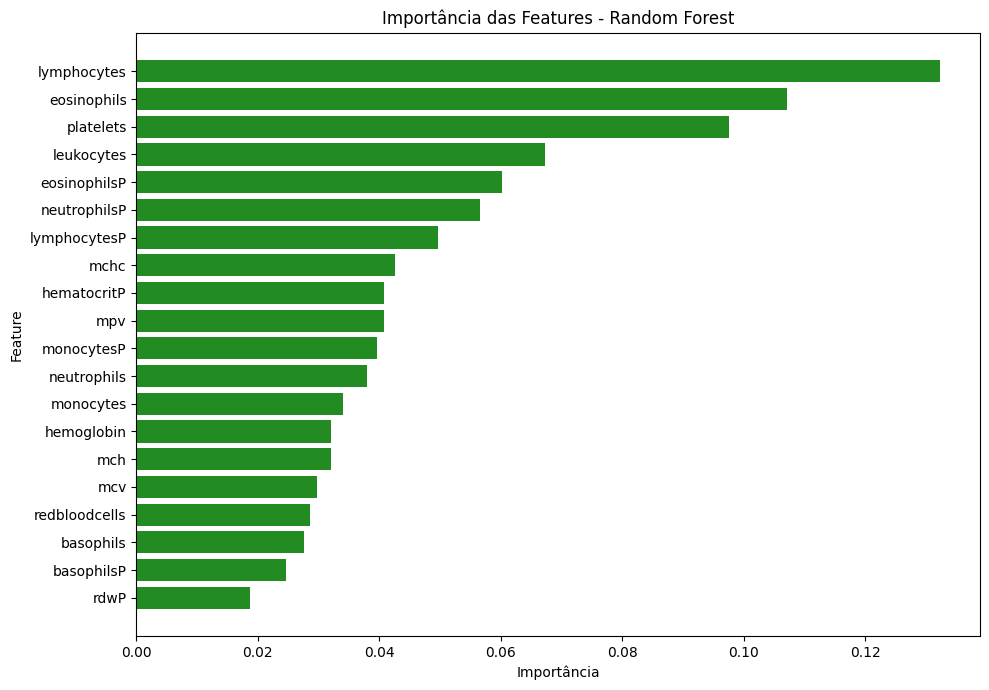

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Importância das features do Random Forest
feature_importance = pd.DataFrame({
    'feature': X_train_exp1.columns,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

print('=== IMPORTÂNCIA DAS FEATURES (RANDOM FOREST) ===')
print(feature_importance.round(4).to_string(index=False))

plt.figure(figsize=(10, max(6, 0.35 * len(feature_importance))))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='forestgreen')
plt.title('Importância das Features - Random Forest')
plt.xlabel('Importância')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

=== Métricas rf_otz_exp1  ===
    Acurácia: 0.8108
    Precisão: 0.7996
    Recall:   0.7517
    F1-Score: 0.7673
    MCC:      0.5492
    AUC:      0.8730


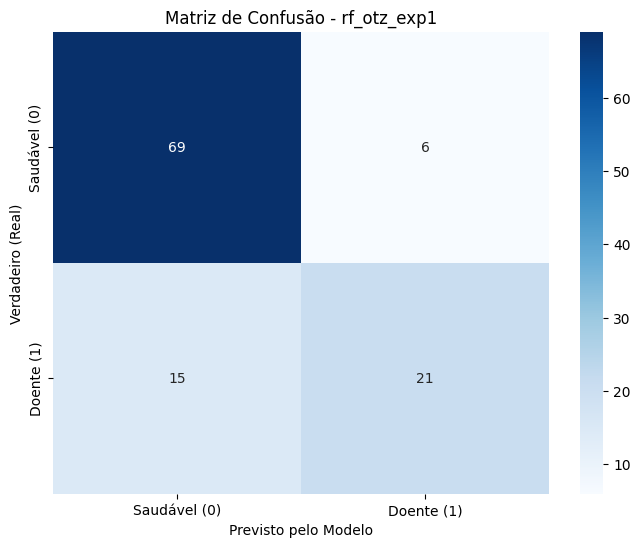

In [8]:
# Avaliar resultados e salvar
y_pred_otz_exp1 = experimento_1.best_model.predict(X_test_exp1)
y_prob_otz_exp1 = experimento_1.best_model.predict_proba(X_test_exp1)[:, 1]

evaluate_model(y_test_exp1, y_pred_otz_exp1, y_prob_otz_exp1, 'rf_otz_exp1')
save_results(y_pred_otz_exp1, y_prob_otz_exp1, 'rf_otz_exp1', caminho)

## Experimento 2: Conjunto com PCA

In [9]:
X_test_exp2 = pd.read_csv(caminho + 'database/processed/splitted/X_test_pca.csv')
X_train_exp2 = pd.read_csv(caminho + 'database/processed/splitted/X_train_pca.csv')
y_test_exp2 = pd.read_csv(caminho + 'database/processed/splitted/y_test.csv').squeeze()
y_train_exp2 = pd.read_csv(caminho + 'database/processed/splitted/y_train.csv').squeeze()

### RF - Default

In [10]:
from sklearn.ensemble import RandomForestClassifier

rf_exp2 = RandomForestClassifier(n_estimators=100, random_state=14)
rf_exp2.fit(X_train_exp2, y_train_exp2)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


=== Métricas rf_def_exp2  ===
    Acurácia: 0.7387
    Precisão: 0.7111
    Recall:   0.6478
    F1-Score: 0.6577
    MCC:      0.3533
    AUC:      0.8157


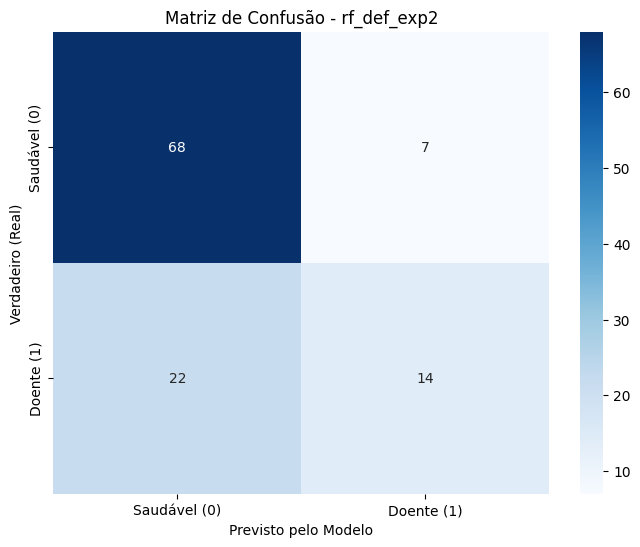

In [11]:
# Avaliar modelo
y_pred_def_exp2 = rf_exp2.predict(X_test_exp2)
y_prob_def_exp2 = rf_exp2.predict_proba(X_test_exp2)[:, 1]

evaluate_model(y_test_exp2, y_pred_def_exp2, y_prob_def_exp2, 'rf_def_exp2')
save_results(y_pred_def_exp2, y_prob_def_exp2, 'rf_def_exp2', caminho)

### RF - Melhorado

In [12]:
# Criar o experimento
experimento_2 = RandomForestExperiment(X_train_exp2, y_train_exp2, 'rf_otz_exp2', caminho)
experimento_2.tune_and_fit(n_trials=50)

[I 2026-08-18 19:05:32,634] A new study created in memory with name: no-name-e054eb39-40eb-4b5b-977d-8e843d7f2ff5


Iniciando otimização do cenário rf_otz_exp2.


Best trial: 0. Best value: 0.802326:   2%|▏         | 1/50 [00:00<00:09,  5.20it/s]

[I 2026-08-18 19:05:32,826] Trial 0 finished with value: 0.8023255813953489 and parameters: {'n_estimators': 81, 'max_depth': 11, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 'log2', 'criterion': 'gini'}. Best is trial 0 with value: 0.8023255813953489.


Best trial: 0. Best value: 0.802326:   4%|▍         | 2/50 [00:00<00:14,  3.41it/s]

[I 2026-08-18 19:05:33,184] Trial 1 finished with value: 0.8023255813953489 and parameters: {'n_estimators': 125, 'max_depth': 19, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 0 with value: 0.8023255813953489.


Best trial: 2. Best value: 0.806202:   6%|▌         | 3/50 [00:01<00:27,  1.70it/s]

[I 2026-08-18 19:05:34,109] Trial 2 finished with value: 0.806201550387597 and parameters: {'n_estimators': 279, 'max_depth': 6, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 2 with value: 0.806201550387597.


Best trial: 2. Best value: 0.806202:   8%|▊         | 4/50 [00:02<00:28,  1.62it/s]

[I 2026-08-18 19:05:34,769] Trial 3 finished with value: 0.7945736434108528 and parameters: {'n_estimators': 132, 'max_depth': 7, 'min_samples_split': 9, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 2 with value: 0.806201550387597.


Best trial: 2. Best value: 0.806202:  10%|█         | 5/50 [00:02<00:22,  2.04it/s]

[I 2026-08-18 19:05:35,051] Trial 4 finished with value: 0.7829457364341086 and parameters: {'n_estimators': 54, 'max_depth': 3, 'min_samples_split': 3, 'min_samples_leaf': 9, 'max_features': 'log2', 'criterion': 'gini'}. Best is trial 2 with value: 0.806201550387597.


Best trial: 2. Best value: 0.806202:  12%|█▏        | 6/50 [00:03<00:23,  1.90it/s]

[I 2026-08-18 19:05:35,651] Trial 5 finished with value: 0.7945736434108528 and parameters: {'n_estimators': 210, 'max_depth': 6, 'min_samples_split': 4, 'min_samples_leaf': 10, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 2 with value: 0.806201550387597.


Best trial: 2. Best value: 0.806202:  14%|█▍        | 7/50 [00:03<00:18,  2.28it/s]

[I 2026-08-18 19:05:35,910] Trial 6 finished with value: 0.7945736434108528 and parameters: {'n_estimators': 60, 'max_depth': 13, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 2 with value: 0.806201550387597.


Best trial: 2. Best value: 0.806202:  16%|█▌        | 8/50 [00:04<00:24,  1.74it/s]

[I 2026-08-18 19:05:36,752] Trial 7 finished with value: 0.8023255813953488 and parameters: {'n_estimators': 231, 'max_depth': 14, 'min_samples_split': 8, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 2 with value: 0.806201550387597.


Best trial: 2. Best value: 0.806202:  18%|█▊        | 9/50 [00:04<00:23,  1.78it/s]

[I 2026-08-18 19:05:37,291] Trial 8 finished with value: 0.7868217054263567 and parameters: {'n_estimators': 126, 'max_depth': 5, 'min_samples_split': 9, 'min_samples_leaf': 10, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 2 with value: 0.806201550387597.


Best trial: 9. Best value: 0.810078:  20%|██        | 10/50 [00:04<00:18,  2.15it/s]

[I 2026-08-18 19:05:37,555] Trial 9 finished with value: 0.8100775193798451 and parameters: {'n_estimators': 55, 'max_depth': 17, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 9 with value: 0.8100775193798451.


Best trial: 10. Best value: 0.813953:  22%|██▏       | 11/50 [00:05<00:18,  2.06it/s]

[I 2026-08-18 19:05:38,084] Trial 10 finished with value: 0.8139534883720931 and parameters: {'n_estimators': 172, 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 10 with value: 0.8139534883720931.


Best trial: 10. Best value: 0.813953:  24%|██▍       | 12/50 [00:05<00:18,  2.02it/s]

[I 2026-08-18 19:05:38,605] Trial 11 finished with value: 0.8100775193798451 and parameters: {'n_estimators': 184, 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 10 with value: 0.8139534883720931.


Best trial: 10. Best value: 0.813953:  26%|██▌       | 13/50 [00:06<00:21,  1.74it/s]

[I 2026-08-18 19:05:39,359] Trial 12 finished with value: 0.8100775193798451 and parameters: {'n_estimators': 276, 'max_depth': 17, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 10 with value: 0.8139534883720931.


Best trial: 10. Best value: 0.813953:  28%|██▊       | 14/50 [00:07<00:19,  1.84it/s]

[I 2026-08-18 19:05:39,832] Trial 13 finished with value: 0.8100775193798451 and parameters: {'n_estimators': 149, 'max_depth': 16, 'min_samples_split': 2, 'min_samples_leaf': 7, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 10 with value: 0.8139534883720931.


Best trial: 10. Best value: 0.813953:  30%|███       | 15/50 [00:07<00:19,  1.82it/s]

[I 2026-08-18 19:05:40,373] Trial 14 finished with value: 0.7906976744186047 and parameters: {'n_estimators': 92, 'max_depth': 17, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 10 with value: 0.8139534883720931.


Best trial: 10. Best value: 0.813953:  32%|███▏      | 16/50 [00:08<00:23,  1.44it/s]

[I 2026-08-18 19:05:41,425] Trial 15 finished with value: 0.8023255813953489 and parameters: {'n_estimators': 235, 'max_depth': 20, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 10 with value: 0.8139534883720931.


Best trial: 10. Best value: 0.813953:  34%|███▍      | 17/50 [00:09<00:24,  1.34it/s]

[I 2026-08-18 19:05:42,285] Trial 16 finished with value: 0.7984496124031009 and parameters: {'n_estimators': 172, 'max_depth': 11, 'min_samples_split': 6, 'min_samples_leaf': 6, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 10 with value: 0.8139534883720931.


Best trial: 10. Best value: 0.813953:  36%|███▌      | 18/50 [00:10<00:20,  1.59it/s]

[I 2026-08-18 19:05:42,646] Trial 17 finished with value: 0.7984496124031009 and parameters: {'n_estimators': 100, 'max_depth': 15, 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 10 with value: 0.8139534883720931.


Best trial: 10. Best value: 0.813953:  38%|███▊      | 19/50 [00:10<00:19,  1.56it/s]

[I 2026-08-18 19:05:43,300] Trial 18 finished with value: 0.8139534883720931 and parameters: {'n_estimators': 183, 'max_depth': 18, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 10 with value: 0.8139534883720931.


Best trial: 10. Best value: 0.813953:  40%|████      | 20/50 [00:11<00:20,  1.50it/s]

[I 2026-08-18 19:05:44,041] Trial 19 finished with value: 0.8100775193798451 and parameters: {'n_estimators': 179, 'max_depth': 9, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 10 with value: 0.8139534883720931.


Best trial: 10. Best value: 0.813953:  42%|████▏     | 21/50 [00:12<00:19,  1.45it/s]

[I 2026-08-18 19:05:44,783] Trial 20 finished with value: 0.8023255813953489 and parameters: {'n_estimators': 212, 'max_depth': 18, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 10 with value: 0.8139534883720931.


Best trial: 10. Best value: 0.813953:  44%|████▍     | 22/50 [00:12<00:18,  1.51it/s]

[I 2026-08-18 19:05:45,356] Trial 21 finished with value: 0.7945736434108528 and parameters: {'n_estimators': 150, 'max_depth': 18, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 10 with value: 0.8139534883720931.


Best trial: 22. Best value: 0.825581:  46%|████▌     | 23/50 [00:13<00:19,  1.38it/s]

[I 2026-08-18 19:05:46,249] Trial 22 finished with value: 0.8255813953488372 and parameters: {'n_estimators': 250, 'max_depth': 20, 'min_samples_split': 6, 'min_samples_leaf': 4, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 22 with value: 0.8255813953488372.


Best trial: 22. Best value: 0.825581:  48%|████▊     | 24/50 [00:14<00:19,  1.33it/s]

[I 2026-08-18 19:05:47,068] Trial 23 finished with value: 0.8255813953488372 and parameters: {'n_estimators': 254, 'max_depth': 19, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 22 with value: 0.8255813953488372.


Best trial: 22. Best value: 0.825581:  50%|█████     | 25/50 [00:15<00:19,  1.28it/s]

[I 2026-08-18 19:05:47,925] Trial 24 finished with value: 0.8100775193798451 and parameters: {'n_estimators': 254, 'max_depth': 20, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 22 with value: 0.8255813953488372.


Best trial: 22. Best value: 0.825581:  52%|█████▏    | 26/50 [00:16<00:19,  1.21it/s]

[I 2026-08-18 19:05:48,854] Trial 25 finished with value: 0.7984496124031009 and parameters: {'n_estimators': 296, 'max_depth': 15, 'min_samples_split': 8, 'min_samples_leaf': 6, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 22 with value: 0.8255813953488372.


Best trial: 22. Best value: 0.825581:  54%|█████▍    | 27/50 [00:16<00:18,  1.23it/s]

[I 2026-08-18 19:05:49,625] Trial 26 finished with value: 0.806201550387597 and parameters: {'n_estimators': 252, 'max_depth': 19, 'min_samples_split': 9, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 22 with value: 0.8255813953488372.


Best trial: 22. Best value: 0.825581:  56%|█████▌    | 28/50 [00:17<00:16,  1.32it/s]

[I 2026-08-18 19:05:50,264] Trial 27 finished with value: 0.8023255813953489 and parameters: {'n_estimators': 203, 'max_depth': 13, 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 22 with value: 0.8255813953488372.


Best trial: 22. Best value: 0.825581:  58%|█████▊    | 29/50 [00:18<00:17,  1.21it/s]

[I 2026-08-18 19:05:51,234] Trial 28 finished with value: 0.813953488372093 and parameters: {'n_estimators': 240, 'max_depth': 19, 'min_samples_split': 4, 'min_samples_leaf': 7, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 22 with value: 0.8255813953488372.


Best trial: 22. Best value: 0.825581:  60%|██████    | 30/50 [00:19<00:16,  1.20it/s]

[I 2026-08-18 19:05:52,096] Trial 29 finished with value: 0.8023255813953489 and parameters: {'n_estimators': 270, 'max_depth': 11, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 'log2', 'criterion': 'gini'}. Best is trial 22 with value: 0.8255813953488372.


Best trial: 22. Best value: 0.825581:  62%|██████▏   | 31/50 [00:20<00:17,  1.08it/s]

[I 2026-08-18 19:05:53,236] Trial 30 finished with value: 0.7984496124031009 and parameters: {'n_estimators': 294, 'max_depth': 16, 'min_samples_split': 2, 'min_samples_leaf': 6, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 22 with value: 0.8255813953488372.


Best trial: 22. Best value: 0.825581:  64%|██████▍   | 32/50 [00:21<00:15,  1.16it/s]

[I 2026-08-18 19:05:53,962] Trial 31 finished with value: 0.8100775193798451 and parameters: {'n_estimators': 202, 'max_depth': 18, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 22 with value: 0.8255813953488372.


Best trial: 22. Best value: 0.825581:  66%|██████▌   | 33/50 [00:21<00:13,  1.28it/s]

[I 2026-08-18 19:05:54,548] Trial 32 finished with value: 0.8100775193798451 and parameters: {'n_estimators': 158, 'max_depth': 20, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 22 with value: 0.8255813953488372.


Best trial: 22. Best value: 0.825581:  68%|██████▊   | 34/50 [00:22<00:13,  1.20it/s]

[I 2026-08-18 19:05:55,478] Trial 33 finished with value: 0.8139534883720931 and parameters: {'n_estimators': 224, 'max_depth': 19, 'min_samples_split': 7, 'min_samples_leaf': 3, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 22 with value: 0.8255813953488372.


Best trial: 22. Best value: 0.825581:  70%|███████   | 35/50 [00:23<00:13,  1.12it/s]

[I 2026-08-18 19:05:56,527] Trial 34 finished with value: 0.813953488372093 and parameters: {'n_estimators': 266, 'max_depth': 18, 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 22 with value: 0.8255813953488372.


Best trial: 22. Best value: 0.825581:  72%|███████▏  | 36/50 [00:24<00:11,  1.23it/s]

[I 2026-08-18 19:05:57,164] Trial 35 finished with value: 0.806201550387597 and parameters: {'n_estimators': 190, 'max_depth': 19, 'min_samples_split': 8, 'min_samples_leaf': 5, 'max_features': 'log2', 'criterion': 'gini'}. Best is trial 22 with value: 0.8255813953488372.


Best trial: 22. Best value: 0.825581:  74%|███████▍  | 37/50 [00:24<00:08,  1.48it/s]

[I 2026-08-18 19:05:57,508] Trial 36 finished with value: 0.7906976744186047 and parameters: {'n_estimators': 106, 'max_depth': 20, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 22 with value: 0.8255813953488372.


Best trial: 22. Best value: 0.825581:  76%|███████▌  | 38/50 [00:25<00:09,  1.33it/s]

[I 2026-08-18 19:05:58,452] Trial 37 finished with value: 0.8178294573643412 and parameters: {'n_estimators': 253, 'max_depth': 16, 'min_samples_split': 7, 'min_samples_leaf': 3, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 22 with value: 0.8255813953488372.


Best trial: 22. Best value: 0.825581:  78%|███████▊  | 39/50 [00:26<00:08,  1.29it/s]

[I 2026-08-18 19:05:59,287] Trial 38 finished with value: 0.8023255813953489 and parameters: {'n_estimators': 248, 'max_depth': 16, 'min_samples_split': 6, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 22 with value: 0.8255813953488372.


Best trial: 22. Best value: 0.825581:  80%|████████  | 40/50 [00:27<00:07,  1.29it/s]

[I 2026-08-18 19:06:00,057] Trial 39 finished with value: 0.8023255813953489 and parameters: {'n_estimators': 218, 'max_depth': 9, 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 22 with value: 0.8255813953488372.


Best trial: 22. Best value: 0.825581:  82%|████████▏ | 41/50 [00:28<00:07,  1.16it/s]

[I 2026-08-18 19:06:01,118] Trial 40 finished with value: 0.8139534883720931 and parameters: {'n_estimators': 264, 'max_depth': 13, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 22 with value: 0.8255813953488372.


Best trial: 22. Best value: 0.825581:  84%|████████▍ | 42/50 [00:29<00:06,  1.20it/s]

[I 2026-08-18 19:06:01,879] Trial 41 finished with value: 0.8100775193798451 and parameters: {'n_estimators': 166, 'max_depth': 18, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 22 with value: 0.8255813953488372.


Best trial: 22. Best value: 0.825581:  86%|████████▌ | 43/50 [00:30<00:05,  1.17it/s]

[I 2026-08-18 19:06:02,785] Trial 42 finished with value: 0.810077519379845 and parameters: {'n_estimators': 237, 'max_depth': 17, 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 22 with value: 0.8255813953488372.


Best trial: 22. Best value: 0.825581:  88%|████████▊ | 44/50 [00:30<00:04,  1.32it/s]

[I 2026-08-18 19:06:03,306] Trial 43 finished with value: 0.7945736434108528 and parameters: {'n_estimators': 139, 'max_depth': 19, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 22 with value: 0.8255813953488372.


Best trial: 22. Best value: 0.825581:  90%|█████████ | 45/50 [00:31<00:04,  1.20it/s]

[I 2026-08-18 19:06:04,341] Trial 44 finished with value: 0.806201550387597 and parameters: {'n_estimators': 283, 'max_depth': 15, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 22 with value: 0.8255813953488372.


Best trial: 22. Best value: 0.825581:  92%|█████████▏| 46/50 [00:32<00:03,  1.20it/s]

[I 2026-08-18 19:06:05,155] Trial 45 finished with value: 0.8100775193798451 and parameters: {'n_estimators': 188, 'max_depth': 17, 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 22 with value: 0.8255813953488372.


Best trial: 22. Best value: 0.825581:  94%|█████████▍| 47/50 [00:33<00:02,  1.15it/s]

[I 2026-08-18 19:06:06,116] Trial 46 finished with value: 0.7984496124031009 and parameters: {'n_estimators': 286, 'max_depth': 20, 'min_samples_split': 9, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 22 with value: 0.8255813953488372.


Best trial: 22. Best value: 0.825581:  96%|█████████▌| 48/50 [00:34<00:01,  1.25it/s]

[I 2026-08-18 19:06:06,762] Trial 47 finished with value: 0.7984496124031009 and parameters: {'n_estimators': 199, 'max_depth': 3, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 22 with value: 0.8255813953488372.


Best trial: 22. Best value: 0.825581:  98%|█████████▊| 49/50 [00:34<00:00,  1.43it/s]

[I 2026-08-18 19:06:07,222] Trial 48 finished with value: 0.7868217054263567 and parameters: {'n_estimators': 116, 'max_depth': 18, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 22 with value: 0.8255813953488372.


Best trial: 22. Best value: 0.825581: 100%|██████████| 50/50 [00:34<00:00,  1.43it/s]


[I 2026-08-18 19:06:07,507] Trial 49 finished with value: 0.7984496124031009 and parameters: {'n_estimators': 67, 'max_depth': 16, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 22 with value: 0.8255813953488372.
Melhor pontuação (CV): 0.8256
Melhores parâmetros:
{'n_estimators': 250, 'max_depth': 20, 'min_samples_split': 6, 'min_samples_leaf': 4, 'max_features': 'log2', 'criterion': 'entropy'}


In [13]:
import optuna
fig = optuna.visualization.plot_param_importances(experimento_2.study)
fig.show()

fig = optuna.visualization.plot_optimization_history(experimento_2.study)
fig.show()

=== Métricas rf_otz_exp2  ===
    Acurácia: 0.7658
    Precisão: 0.7513
    Recall:   0.6822
    F1-Score: 0.6966
    MCC:      0.4280
    AUC:      0.8207


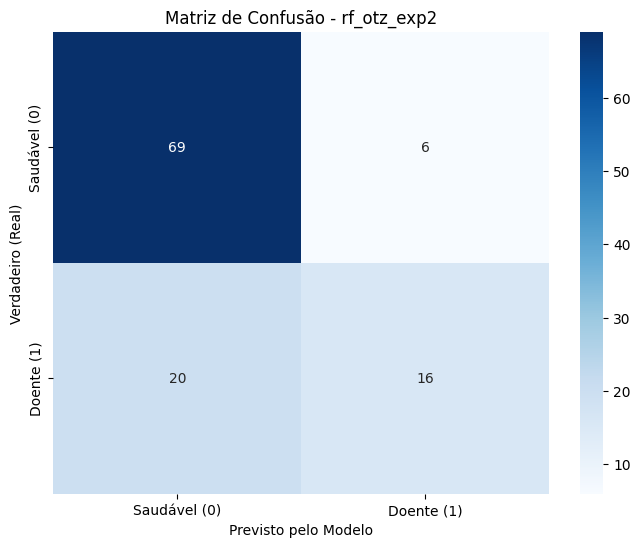

In [14]:
# Avaliar resultados e salvar
y_pred_otz_exp2 = experimento_2.best_model.predict(X_test_exp2)
y_prob_otz_exp2 = experimento_2.best_model.predict_proba(X_test_exp2)[:, 1]

evaluate_model(y_test_exp2, y_pred_otz_exp2, y_prob_otz_exp2, 'rf_otz_exp2')
save_results(y_pred_otz_exp2, y_prob_otz_exp2, 'rf_otz_exp2', caminho)